<center> <h1> Predictive Targeting in Bank Marketing Campaigns using Deep Learning Architecture and Big Data</h1></center>

In [381]:
import warnings
warnings.filterwarnings('ignore')

# Install Packages
#!python3 -m pip install imblearn hdfs --break-system-packages
#!pip install catboost

In [383]:
# Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import json
import tensorflow as tf
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
#from pyspark.sql.types import *
#from pyspark.sql import functions
from imblearn.over_sampling import SMOTE
from sklearn import metrics
#from hdfs import InsecureClient

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

## Custom Functions

In [386]:
# Save model locally and upload to HDFS
def save_model(model, filename):
    hdfs_path = f'/marketing_campaign/models/{filename}.h5'
    
    print('----Exporting model locally.')
    # Save model locally
    try:
        model.save(f'{filename}.h5')
        print(f'Model was saved locally as {filename}.h5')
    except Exception as e:
        print('Failed to export the model.')
        print('Error details:', e)
        
    
    print('----Uploading model to HDFS.')
    # Upload file to HDFS
    try:
        client = InsecureClient('http://localhost:9870', user='hduser')

        with open(f'{filename}.h5', 'rb') as f:
            client.write(hdfs_path, f, overwrite=True)

        print(f"Model saved to HDFS at {hdfs_path}")
    except Exception as e:
        print('Failed to upload model to HDFS.')
        print('Error details:', e)


# This function will initialize model training
# X - independent variables
# y - target variables
# model - dictionary of models to be used
# param_grid - corresponding parameter grid per model
# split_size - train, test split size with 20% default
# cv - number of folds
def init_training(X_train, y_train, X_test, y_test, model, param_grid, split_size=0.20, cv=3, print_results=True):

    # Create variables to store model and results
    results=[]
    trained_models={}

    #Loop through each model
    for name, clf in models.items():
        print(clf, name)
        grid_search = GridSearchCV(clf, param_grid[name], cv=cv, scoring='accuracy')

        # Fit the grid search
        grid_search.fit(X_train, y_train)
        
        # Best parameters and best score
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_
        
        # Get best model on the training data
        best_model = grid_search.best_estimator_

        # Predict Values
        X_pred = best_model.predict(X_train)
        y_pred = best_model.predict(X_test)
        
        # Store the Accuracy and F1
        train_acc = accuracy_score(y_train, X_pred)
        test_acc = accuracy_score(y_test, y_pred)
        
        train_f1 = f1_score(y_train, X_pred, average="weighted") 
        test_f1 = f1_score(y_test, y_pred, average="weighted")


        # Consolidate results
        results.append({'Model':name,
                    'Accuracy': test_acc,
                    'F1':test_f1,
                   })

        # Store best model
        trained_models[name]= best_model
        
        # Display the training and test score
        if print_results==True: 
            print(f'Model: {name}:')
            print(f'Best Params:{best_params}')
            print(f'Accuracy score for train:{train_acc: .4f}, test:{test_acc: .4f}.')
            print(f'F1 score for train: {train_f1:.4f}, test F1: {test_f1:.4f}')
            print('\n')
            print(classification_report(y_test, y_pred))
        else:
            pass

    # Return model training results and trained_models to be used for predictions
    return results, trained_models

# This function displays a performance comparison across all trained models
def gen_model_training_summary(result,title=''):
    # Convert to DataFrame and sort by R2 score
    results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=True)
    
    # Create subplots
    fig, ax = plt.subplots(2, 1, figsize=(15, 15))
    
    # Plot Accuracy Score
    sns.barplot(ax=ax[0], x=results_df.Model, y=results_df.Accuracy, palette="Blues")
    ax[0].set_title("Accuracy Score Comparison")
    ax[0].set_ylabel("Accuracy Score")
    ax[0].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Plot MAE
    sns.barplot(ax=ax[1], x=results_df.Model, y=results_df.F1, palette="Greens")
    ax[1].set_title("F1 Score Comparison")
    ax[1].set_ylabel("F1 Score")
    ax[1].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Adjust layout and show plot
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## Import Dataset from HDFS

In [389]:
# df = spark.read.load('hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv', format="csv", header="true")
# df.printSchema()

In [391]:
#campaign_data=df.toPandas()

campaign_data=pd.read_csv('marketing_data.csv')
campaign_data.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [393]:
campaign_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     8252 non-null   object
 17  target       45211 non-null  object
dtypes: int64(8), object(10)
memory usage: 6.2+ MB


In [395]:
campaign_data.describe()

,Unnamed: 0,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22605.000000,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,13051.435847,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,0.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,11302.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,22605.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,33907.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,45210.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


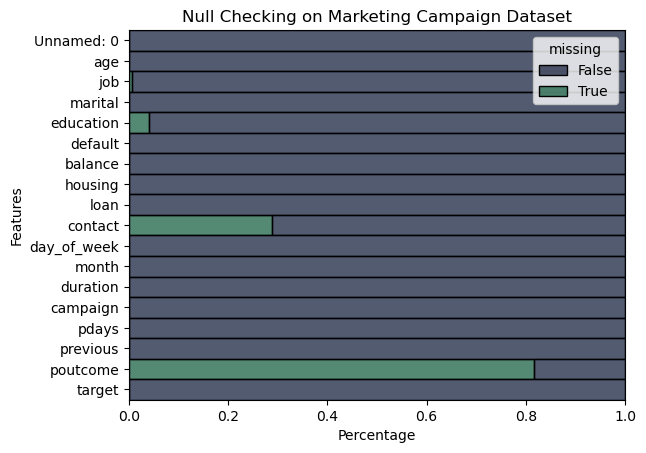

In [397]:
sns.set_palette('cubehelix')

sns.histplot(data=campaign_data.isnull().melt(value_name='missing'),
           y='variable',
           hue='missing',
           multiple='fill')

plt.title('Null Checking on Marketing Campaign Dataset')
plt.xlabel('Percentage')
plt.ylabel('Features')

plt.show()

In [398]:
# Check for duplicates
print(f'Number of duplicates in the dataframe: {campaign_data.duplicated().sum()}.')

Number of duplicates in the dataframe: 0.


In [401]:
# Check for unique 
campaign_data.nunique()

Unnamed: 0     45211
age               77
job               11
marital            3
education          3
default            2
balance         7168
housing            2
loan               2
contact            2
day_of_week       31
month             12
duration        1573
campaign          48
pdays            559
previous          41
poutcome           3
target             2
dtype: int64

## Data Preparation and Visualisation

In [404]:
cols = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
campaign_data[cols] = campaign_data[cols].apply(pd.to_numeric, errors='coerce')

In [406]:
try:
    df=campaign_data.copy()
    df.drop(columns=['Unnamed: 0','poutcome','pdays', 'day_of_week','month,'], inplace=True)    
#    df.drop(columns=['poutcome','_c0','pdays', 'day_of_week','month'], inplace=True)
    df.dropna(axis=0, inplace=True)
    y = df['target']
    X = df.drop(columns=['target'])
except Exception as e:
    print('No changes made in the dataset.')
    print(f'Exception:{e}')

X.isnull().sum()

No changes made in the dataset.
Exception:"['month,'] not found in axis"


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
duration     0
campaign     0
previous     0
dtype: int64

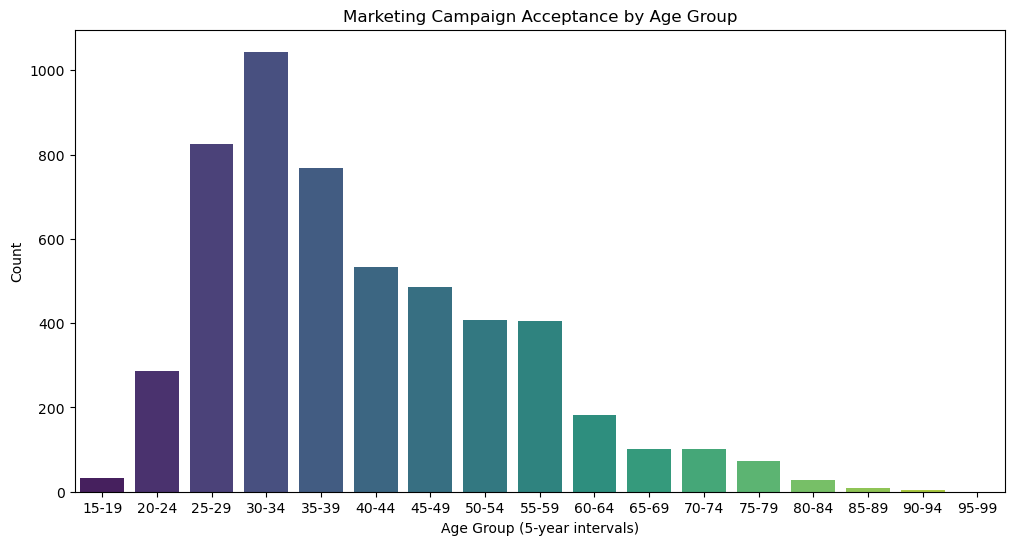

In [408]:
df_yes = df[df['target'] == 'yes'].copy() 

min_age = df_yes['age'].min() // 5 * 5
max_age = (df_yes['age'].max() // 5 + 1) * 5
bins = range(min_age, max_age + 1, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df_yes['age_group'] = pd.cut(df_yes['age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(12, 6))
sns.countplot(x='age_group', data=df_yes, order=labels, palette='viridis')
plt.xlabel('Age Group (5-year intervals)')
plt.ylabel('Count')
plt.title('Marketing Campaign Acceptance by Age Group')
plt.show()


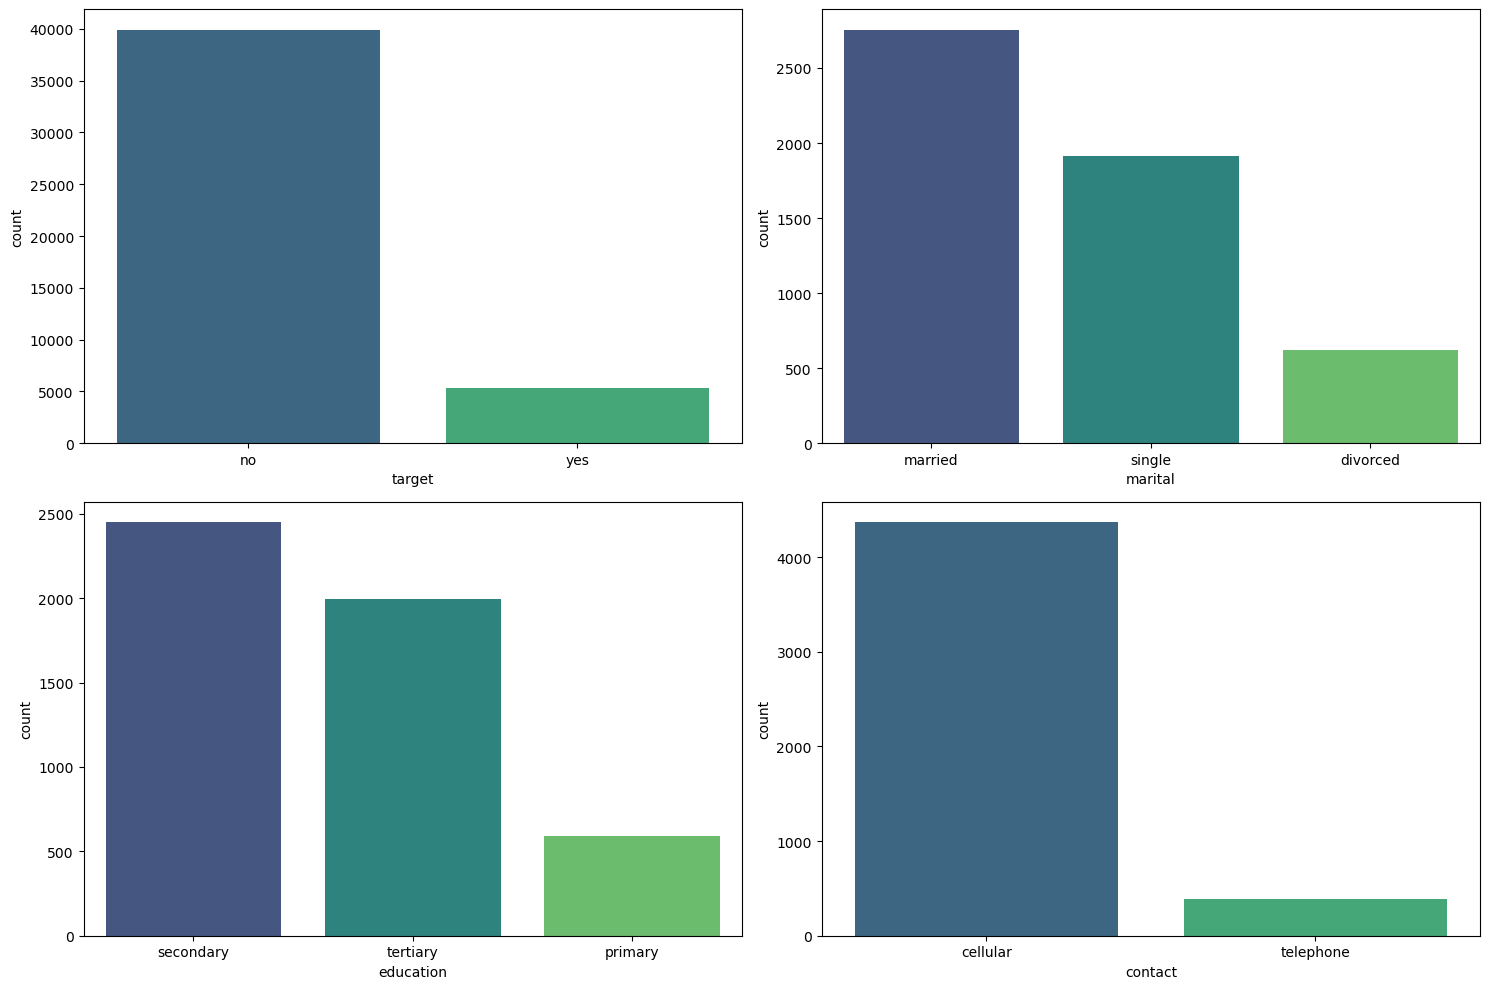

25/10/03 11:37:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:37:41 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:37:51 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:38:01 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/03 11:38:11 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

...

25/10/03 11:44:51 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:45:01 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/03 11:45:11 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/03 11:45:21 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:45:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [410]:

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten() 

sns.countplot(x='target', data=campaign_data, palette='viridis', ax=axs[0])
sns.countplot(x='marital', data=df_yes, palette='viridis', ax=axs[1])
sns.countplot(x='education', data=df_yes, palette='viridis', ax=axs[2])
sns.countplot(x='contact', data=df_yes, palette='viridis', ax=axs[3])

plt.tight_layout()
plt.show()


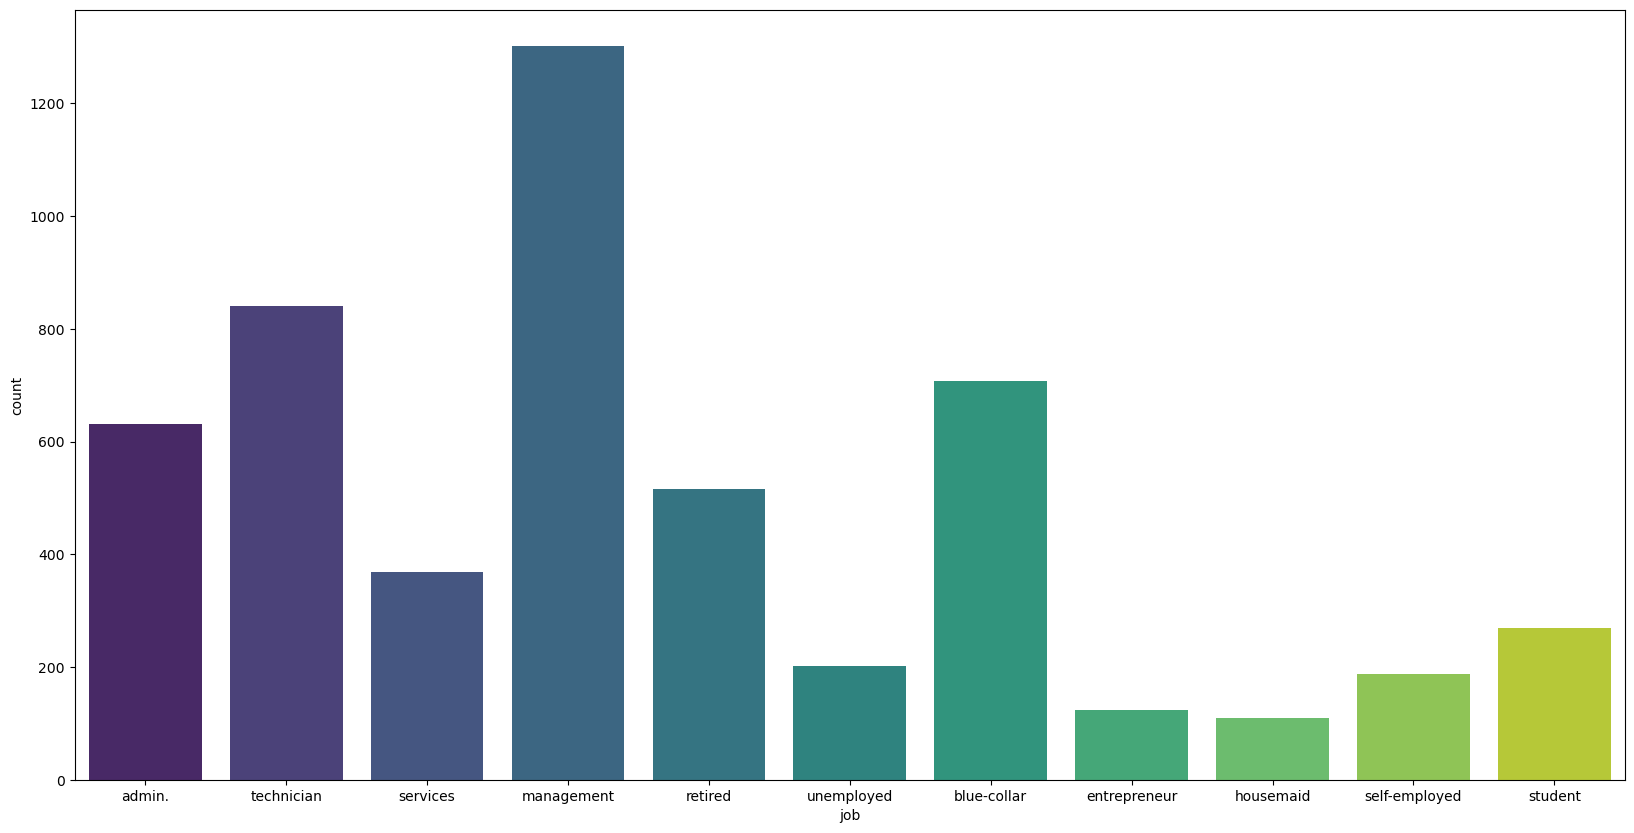

In [412]:
plt.figure(figsize=(20,10))
sns.countplot(x='job', data=df_yes, palette='viridis')
plt.show()

In [414]:
# plt.figure(figsize=(10, 6))

# corr_data=X
# corr_data['target']=y

# # Select only numeric features
# numeric_df = df.select_dtypes(include=['number'])

# sns.heatmap(corr_data.corr(), annot=True, fmt=".1f", cmap='coolwarm')

# plt.title("Correlation Matrix (Numeric Features Only)")
# plt.show()

X


,age,job,marital,education,default,balance,housing,loan,duration,campaign,previous
0,58,management,married,tertiary,no,2143,yes,no,261,1,0
1,44,technician,single,secondary,no,29,yes,no,151,1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,76,1,0
5,35,management,married,tertiary,no,231,yes,no,139,1,0
6,28,management,single,tertiary,no,447,yes,yes,217,1,0
...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,977,3,0
45207,71,retired,divorced,primary,no,1729,no,no,456,2,0
45208,72,retired,married,secondary,no,5715,no,no,1127,5,3
45209,57,blue-collar,married,secondary,no,668,no,no,508,4,0


## Machine Learning

In [418]:

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

y=y.map({'yes': 1, 'no': 0})

# All columns with dtype "object" or "category"
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
# One-Hot Encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.head()


# def label_encoder_df(df):
#     df_encoded = df.copy()
#     le = LabelEncoder()
#     for col in df_encoded.select_dtypes(include=["object"]).columns:
#         df_encoded[col] = le.fit_transform(df_encoded[col])
#     return df_encoded

# X_encoded = label_encoder_df(X)
# y_df = y.to_frame() 
# y_encoded = label_encoder_df(y_df)
# print(X_encoded.head(),'\n', y_encoded.head())

X.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign',
       'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_secondary', 'education_tertiary'],
      dtype='object')

### Smote

In [499]:

# # Split into train and test (important: apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.4, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


pd.Series(y_train_res).value_counts()


target
0    26720
1    10688
Name: count, dtype: int64

In [501]:
scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train_res)
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.fit_transform(X_test)


# Artificial Neural Network - Classification

In [504]:
model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'), 
    Dropout(0.3),
    Dense(32, activation='relu'),  
    Dense(1, activation='sigmoid')                             
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)

In [506]:
early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=10,          
    restore_best_weights=True  
)

history = model.fit(
    X_train_scaled, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8796 - loss: 0.3446 - val_accuracy: 0.2827 - val_loss: 1.1625
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.8915 - loss: 0.2666 - val_accuracy: 0.3031 - val_loss: 1.1778
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - accuracy: 0.8894 - loss: 0.2619 - val_accuracy: 0.3094 - val_loss: 1.2048
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.8939 - loss: 0.2546 - val_accuracy: 0.3153 - val_loss: 1.2157
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.8946 - loss: 0.2466 - val_accuracy: 0.3339 - val_loss: 1.1457
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.8897 - loss: 0.2571 - val_accuracy: 0.3404 - val_loss: 1.1465
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.8953 - loss: 0.2517 - val_accuracy: 0.3726 - val_loss: 1.1158
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8922 - loss: 0.2547 - va

In [507]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.8874 - loss: 0.2620
Test Accuracy: 88.70%


In [508]:
y_pred_results = model.predict(X_test_scaled)

y_pred_results = [round(x[0]) for x in y_pred_results]

# Now compute accuracy and F1
acc = accuracy_score(y_test, y_pred_results)
f1  = f1_score(y_test, y_pred_results, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


print(classification_report(y_pred_results, y_test))

405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step
Accuracy: 0.8870
F1 Score: 0.8857
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     11528
           1       0.49      0.51      0.50      1430

    accuracy                           0.89     12958
   macro avg       0.71      0.72      0.72     12958
weighted avg       0.89      0.89      0.89     12958



# Traditional Classification Models

In [512]:
# Classification param grid
param_grid = {
    'Decision Tree': {
        'max_depth': [2, 4, 6],
        'random_state': [0]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10, 20],
        'random_state': [0],
    },
    'Logistic Regression': {
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
        'l1_ratio': [0.0, 0.5, 1.0],
        'C': [0.1, 1.0, 10],
        'max_iter': [2000]
    },
    'CatBoost': {
        'iterations': [100, 200],
        'learning_rate': [0.05, 0.1],
        'depth': [ 6, 8],
        'scale_pos_weight': [1, 2]   # imbalance handling
    }
}

# Classification models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=0)
}


In [514]:
results, trad_models_results = init_training(X_train_scaled, y_train_res, X_test_scaled, y_test, model, param_grid, cv=3, print_results=True)

DecisionTreeClassifier(random_state=0) Decision Tree
Model: Decision Tree:
Best Params:{'max_depth': 4, 'random_state': 0}
Accuracy score for train: 0.8327, test: 0.8369.
F1 score for train: 0.8301, test F1: 0.8557


              precision    recall  f1-score   support

           0       0.96      0.85      0.90     11452
           1       0.39      0.70      0.50      1506

    accuracy                           0.84     12958
   macro avg       0.67      0.78      0.70     12958
weighted avg       0.89      0.84      0.86     12958

RandomForestClassifier(random_state=0) Random Forest
Model: Random Forest:
Best Params:{'max_depth': 20, 'n_estimators': 50, 'random_state': 0}
Accuracy score for train: 0.9913, test: 0.8731.
F1 score for train: 0.9913, test F1: 0.8761


              precision    recall  f1-score   support

           0       0.93      0.92      0.93     11452
           1       0.46      0.51      0.48      1506

    accuracy                           0.87     12958


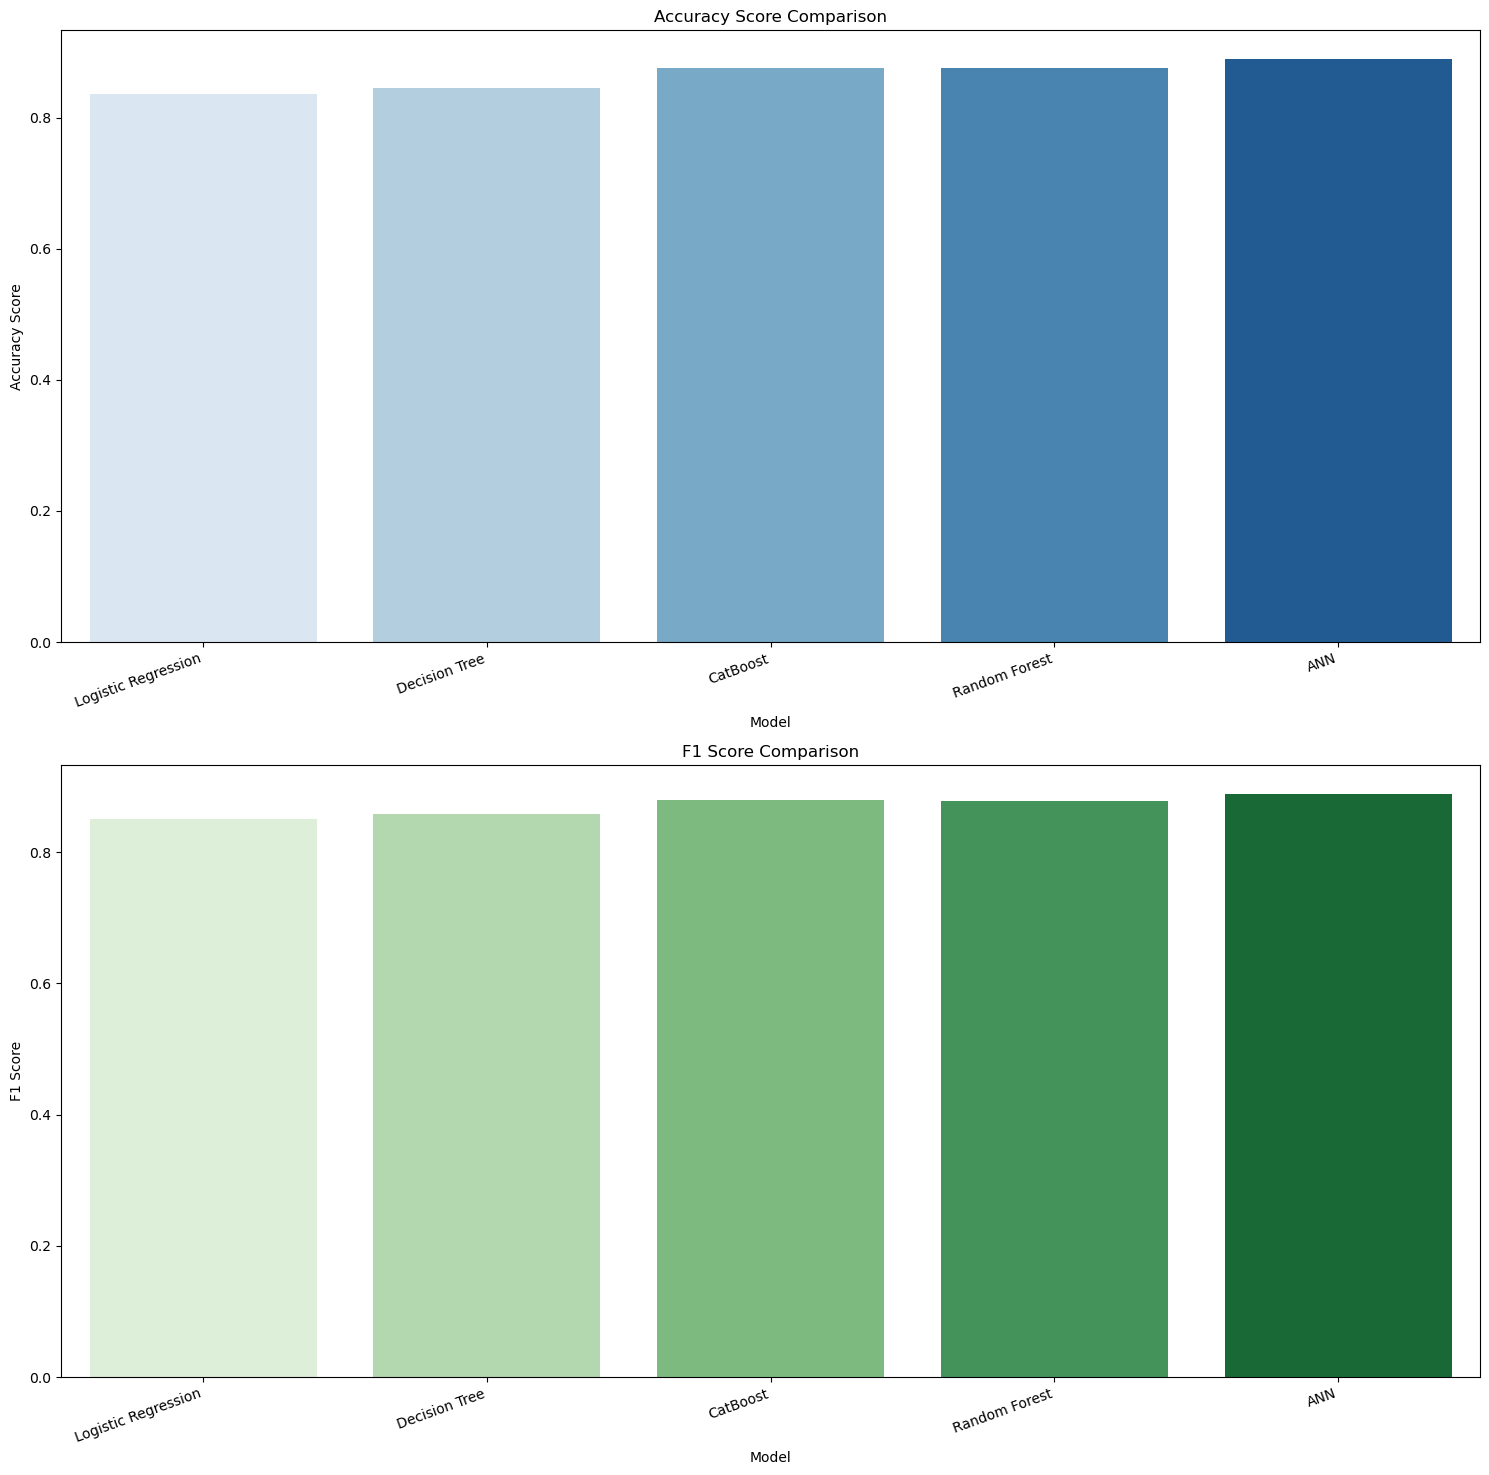

In [438]:
results.append({
    'Model': 'ANN',
    'Accuracy': acc,
    'F1': f1
})

gen_model_training_summary(results)

In [36]:
save_model(model, 'ann_model')

----Exporting model locally.
Model was saved locally as ann_model.h5
----Uploading model to HDFS.
Failed to upload model to HDFS.
Error details: name 'InsecureClient' is not defined
